# Creating synthetic data

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Create synthetic data
X = tf.range(-30, 30, 1, dtype=tf.float32)
X = tf.reshape(X, (-1, 1))  # Reshape to (N, 1)
Y = tf.zeros(X.shape[0])

# Assign labels based on X values
mask_1 = tf.where(X[:, 0] <= -10)
mask_05 = tf.where((X[:, 0] > -10) & (X[:, 0] < 10))
mask_0 = tf.where(X[:, 0] >= 10)

# Create Y tensor and assign values
Y_list = np.zeros(X.shape[0])
Y_list[mask_1.numpy().flatten()] = 1.0
Y_list[mask_05.numpy().flatten()] = 0.5
Y_list[mask_0.numpy().flatten()] = 0.0

Y = tf.constant(Y_list, dtype=tf.float32)

## Plotting the data

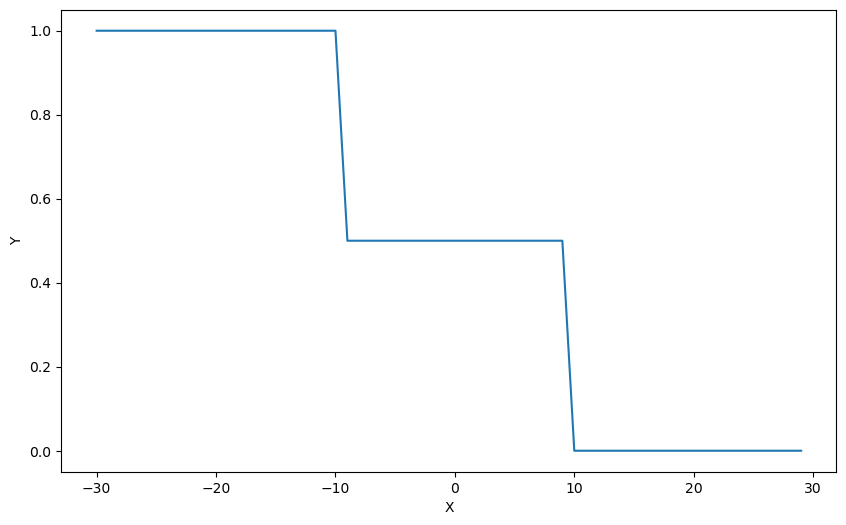

In [2]:
# Create a plot of X against Y
plt.figure(figsize=(10, 6))
plt.plot(X.numpy(), Y.numpy())

# Add X and Y labels to the plot
plt.xlabel('X')
plt.ylabel('Y')

# Display the plot
plt.show()

# Defining the Perceptron Model

## Single Layer Perceptron (Manual Implementation)

In [3]:
class SingleLayerPerceptron:
    def __init__(self, input_size):
        # Initialize weights and bias
        self.weights = tf.Variable(tf.random.normal([input_size]), trainable=True)
        self.bias = tf.Variable(tf.random.normal([1]), trainable=True)

    def activation_function(self, x):
        # Step function as the activation function
        return 1.0 if x >= 0 else 0.0

    def predict(self, x):
        # Calculate the linear combination of inputs and weights
        linear_output = tf.reduce_sum(tf.multiply(self.weights, x)) + self.bias
        # Apply the activation function to get the predicted label
        predicted_label = self.activation_function(linear_output.numpy())
        return predicted_label

    def train(self, X, Y, learning_rate=0.01, epochs=100):
        for epoch in range(epochs):
            for i in range(X.shape[0]):
                # Get the current input and label
                x = X[i]
                y = Y[i]

                # Make a prediction
                predicted = self.predict(x)

                # Update weights and bias based on the error
                error = y - predicted
                self.weights.assign_add(learning_rate * error * x)
                self.bias.assign_add(learning_rate * error)

## Neural Network with Keras (Recommended)

In [4]:
from tensorflow import keras
from tensorflow.keras import layers

class SingleLayerNet(keras.Model):
    def __init__(self, hidden_neurons, output_size):
        super(SingleLayerNet, self).__init__()
        # Define the hidden layer with 1 input feature and hidden_neurons neurons
        self.hidden_layer = layers.Dense(hidden_neurons, activation='sigmoid')

        # Define the output layer with hidden_neurons input features and output_size neurons
        self.output_layer = layers.Dense(output_size, activation='sigmoid')

    def call(self, x):
        # Pass the input through the hidden layer with sigmoid activation
        hidden_output = self.hidden_layer(x)

        # Pass the hidden layer output through the output layer with sigmoid activation
        y_pred = self.output_layer(hidden_output)

        return y_pred

In [5]:
# Instantiate the model
# 2 represents two neurons in one hidden layer
perceptron = SingleLayerNet(hidden_neurons=2, output_size=1)

# Build the model by passing a sample input
perceptron.build(input_shape=(None, 1))
perceptron.summary()

/Users/sun/Installs/miniforge3/envs/dl/lib/python3.12/site-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'single_layer_net', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "single_layer_net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Training the Model

In [6]:
# Compile the model with binary crossentropy loss and SGD optimizer
perceptron.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    metrics=['mse']
)

In [7]:
# Reshape Y to match model output shape (N, 1)
Y_reshaped = tf.reshape(Y, (-1, 1))

# Split data into training and validation sets (90/10 split)
split_idx = int(0.9 * len(X))
X_train, X_val = X[:split_idx], X[split_idx:]
Y_train, Y_val = Y_reshaped[:split_idx], Y_reshaped[split_idx:]

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")

Training set size: 54
Validation set size: 6


## The Training Loop

In [8]:
# Train the model
epochs = 5000
batch_size = 32

# Create custom callbacks for logging
history = perceptron.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=epochs,
    batch_size=batch_size,
    verbose=0  # Set to 1 for progress bar
)

# Extract training and validation losses
train_losses = history.history['loss']
val_losses = history.history['val_loss']

# Print progress
for epoch in [999, 1999, 2999, 3999, 4999]:
    print(f"Epoch {epoch + 1:>4d} | Train Loss: {train_losses[epoch]:.6f} | Val Loss: {val_losses[epoch]:.6f}")

Epoch 1000 | Train Loss: 0.338460 | Val Loss: 0.086068
Epoch 2000 | Train Loss: 0.330871 | Val Loss: 0.060209
Epoch 3000 | Train Loss: 0.327285 | Val Loss: 0.059693
Epoch 4000 | Train Loss: 0.317425 | Val Loss: 0.037264
Epoch 5000 | Train Loss: 0.294179 | Val Loss: 0.017710


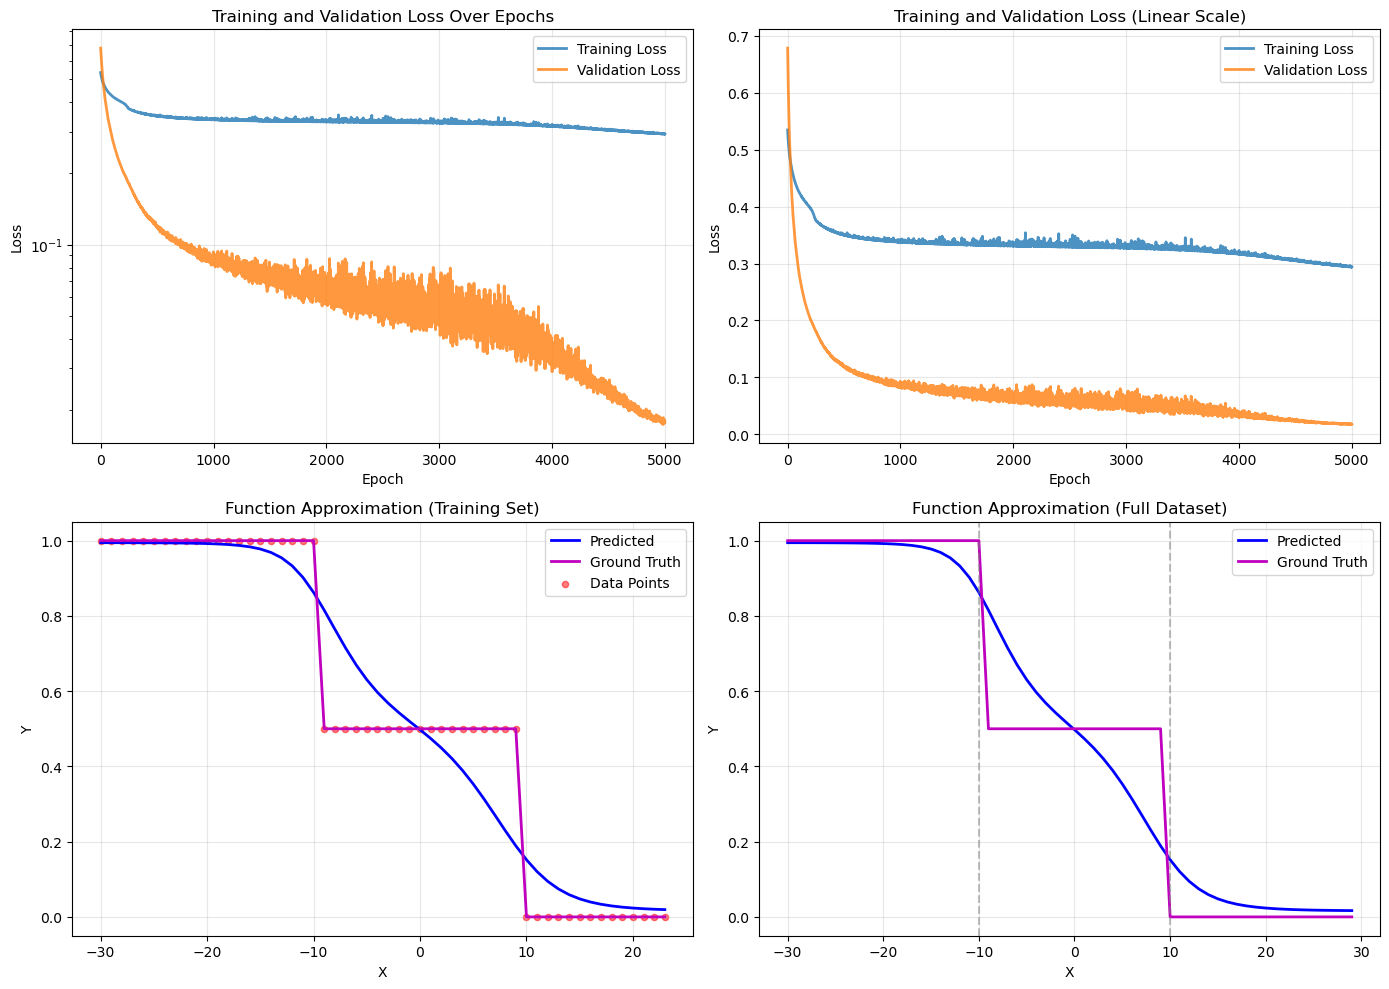

In [9]:
# Create a comprehensive visualization with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Training and Validation Loss Curves (Log Scale)
axes[0, 0].plot(train_losses, label='Training Loss', linewidth=2, alpha=0.8)
axes[0, 0].plot(val_losses, label='Validation Loss', linewidth=2, alpha=0.8)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss Over Epochs')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_yscale('log')  # Log scale for better visualization of convergence

# Plot 2: Loss Curve (Linear Scale)
axes[0, 1].plot(train_losses, label='Training Loss', linewidth=2, alpha=0.8)
axes[0, 1].plot(val_losses, label='Validation Loss', linewidth=2, alpha=0.8)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Training and Validation Loss (Linear Scale)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Function Approximation - Training Data
predicted_values_train = perceptron.predict(X_train, verbose=0)
axes[1, 0].plot(X_train.numpy(), predicted_values_train, 'b-', linewidth=2, label='Predicted')
axes[1, 0].plot(X_train.numpy(), Y_train.numpy(), 'm-', linewidth=2, label='Ground Truth')
axes[1, 0].scatter(X_train.numpy(), Y_train.numpy(), color='red', s=20, alpha=0.5, label='Data Points')
axes[1, 0].set_xlabel('X')
axes[1, 0].set_ylabel('Y')
axes[1, 0].set_title('Function Approximation (Training Set)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Function Approximation - Full Dataset
predicted_values_full = perceptron.predict(X, verbose=0)
axes[1, 1].plot(X.numpy(), predicted_values_full, 'b-', linewidth=2, label='Predicted')
axes[1, 1].plot(X.numpy(), Y.numpy(), 'm-', linewidth=2, label='Ground Truth')
axes[1, 1].axvline(x=-10, color='gray', linestyle='--', alpha=0.5)  # Decision boundary
axes[1, 1].axvline(x=10, color='gray', linestyle='--', alpha=0.5)   # Decision boundary
axes[1, 1].set_xlabel('X')
axes[1, 1].set_ylabel('Y')
axes[1, 1].set_title('Function Approximation (Full Dataset)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Print final statistics
print(f"\n{'='*50}")
print(f"Final Training Loss: {train_losses[-1]:.6f}")
print(f"Final Validation Loss: {val_losses[-1]:.6f}")
print(f"Improvement: {((train_losses[0] - train_losses[-1]) / train_losses[0] * 100):.2f}%")
print(f"{'='*50}")


Final Training Loss: 0.294179
Final Validation Loss: 0.017710
Improvement: 44.97%


## Model Performance Analysis

In [11]:
# Model Performance Analysis
train_preds = perceptron.predict(X_train, verbose=0).squeeze()
val_preds = perceptron.predict(X_val, verbose=0).squeeze()

# Calculate Mean Squared Error (MSE) for regression evaluation
train_mse = np.mean((train_preds - Y_train.numpy().squeeze())**2)
val_mse = np.mean((val_preds - Y_val.numpy().squeeze())**2)

# Calculate Mean Absolute Error (MAE)
train_mae = np.mean(np.abs(train_preds - Y_train.numpy().squeeze()))
val_mae = np.mean(np.abs(val_preds - Y_val.numpy().squeeze()))

print("Model Performance Metrics:")
print(f"  Training MSE:   {train_mse:.6f}")
print(f"  Validation MSE: {val_mse:.6f}")
print(f"  Training MAE:   {train_mae:.6f}")
print(f"  Validation MAE: {val_mae:.6f}")
print(f"\nOverfitting Check:")
overfitting_ratio = val_mse / train_mse if train_mse > 0 else 0
print(f"  Val MSE / Train MSE Ratio: {overfitting_ratio:.2f}")
if overfitting_ratio > 1.1:
    print("  ⚠️  Possible overfitting detected")
else:
    print("  ✓ Good generalization")

Model Performance Metrics:
  Training MSE:   0.012574
  Validation MSE: 0.000309
  Training MAE:   0.074319
  Validation MAE: 0.017554

Overfitting Check:
  Val MSE / Train MSE Ratio: 0.02
  ✓ Good generalization
